In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

2026-01-01 23:30:08.116012: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-01 23:30:08.583745: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-01 23:30:10.162191: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/lucas/projects/spin-system/venv/lib/python3.12/site-packages/keras/src/export/tf2onnx

In [2]:
%reload_ext autoreload
%autoreload 2
from spin_engine.interactions.standard import PeriodicNearestNeighborInteraction, CurieWeissInteraction
from spin_engine.models.ising import IsingSystem
from spin_engine.models.spherical import SphericalSystem
from spin_engine.measurements import Energy, Magnetization

In [3]:
L = 32
replicas = 16
interaction = PeriodicNearestNeighborInteraction().generate(D=2, L=L)

# Visual Verification of Spin Systems

I0000 00:00:1767321016.623895   12248 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


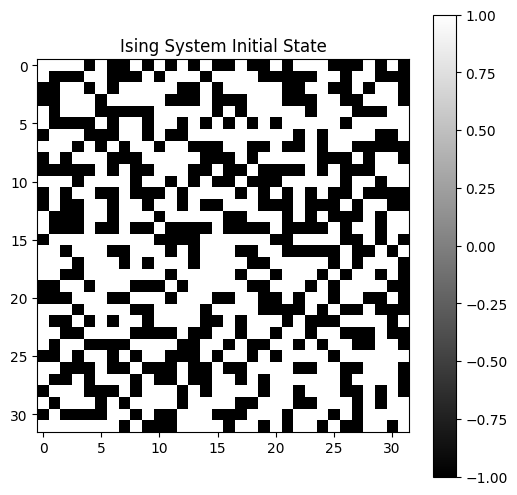

In [4]:
ising = IsingSystem(L, replicas, interaction, initial_magnetization=0.1)
state = ising.spin_state.numpy()[0, :, :]

plt.figure(figsize=(6, 6))
plt.imshow(state, cmap='gray')
plt.title('Ising System Initial State')
plt.colorbar()
plt.show()

In [5]:
Energy(ising).compute()

<tf.Tensor: shape=(16,), dtype=float32, numpy=
array([ 32., -40.,  16.,  -4., -32., -76.,  28., -24., -60., -52.,  -4.,
       -28.,  24.,   8., -48.,  52.], dtype=float32)>

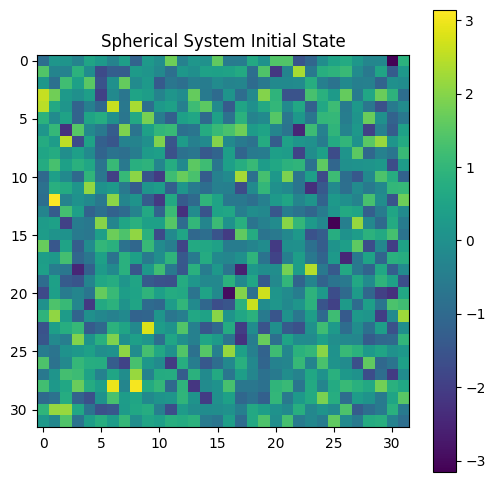

In [6]:
spherical = SphericalSystem(L, replicas, interaction, spherical_constraint=True)
state_sph = spherical.spin_state.numpy()[0, :, :]

plt.figure(figsize=(6, 6))
plt.imshow(state_sph, cmap='viridis')
plt.title('Spherical System Initial State')
plt.colorbar()
plt.show()